# 07. 프로젝트용 시각 데이터 구성 및 모델 성능 평가

## 학습 목표
1. 프로젝트 목적에 맞는 시각 데이터셋을 구성한다.
2. 이미지-라벨을 이미지 단위 학습 테이블로 변환한다.
3. 베이스라인 모델을 학습하고 성능을 정량 평가한다.

---

이 노트북은 객체 검출 데이터(YOLO 라벨)를 **이미지 단위 결함 분류** 실습용으로 재구성해,
데이터 구성부터 평가까지 한 번에 수행합니다.

In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "model_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper",
}

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)

DATA_ROOT: C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset\pcb-defect-dataset
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\model_eval


## 1) 시각 데이터 구성 규칙 정의

객체 검출 라벨(`class cx cy w h`)을 이미지 단위 레이블로 변환합니다.

### 이미지 단위 클래스 정의 규칙
- 한 이미지에 bbox가 여러 개인 경우:
  - **가장 많이 등장한 class**를 대표 클래스(`target_class`)로 사용
- 동률인 경우:
  - class id가 작은 값을 사용 (재현성 확보)

> 실제 프로젝트에서는 멀티라벨 분류 또는 객체 검출 그대로 학습하는 것이 더 적절할 수 있습니다.

In [ ]:
SPLITS = ["train", "val", "test"]


def parse_yolo_label(path: Path):
    items = []
    text = path.read_text(encoding="utf-8").strip()
    if not text:
        return items
    for line in text.splitlines():
        p = line.split()
        if len(p) != 5:
            continue
        cls, cx, cy, w, h = map(float, p)
        items.append((int(cls), cx, cy, w, h))
    return items


def choose_target_class(classes):
    if len(classes) == 0:
        return None
    cnt = Counter(classes)
    max_freq = max(cnt.values())
    cands = sorted([k for k, v in cnt.items() if v == max_freq])
    return cands[0]


def build_image_table(split: str):
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"
    rows = []

    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        anns = parse_yolo_label(lbl_path)
        classes = [a[0] for a in anns if a[0] in CLASS_NAMES]
        target = choose_target_class(classes)
        if target is None:
            continue

        rows.append({
            "split": split,
            "stem": img_path.stem,
            "image_path": str(img_path),
            "label_path": str(lbl_path),
            "num_boxes": len(classes),
            "target_class": target,
            "target_name": CLASS_NAMES[target],
        })

    return pd.DataFrame(rows)

img_df = pd.concat([build_image_table(s) for s in SPLITS], ignore_index=True)
print("구성된 이미지 수:", len(img_df))
display(img_df.head())

# RTX 3060 : 약 3분 소요

구성된 이미지 수: 8001


,split,stem,image_path,label_path,num_boxes,target_class,target_name
0,train,l_light_01_missing_hole_01_1_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole
1,train,l_light_01_missing_hole_01_2_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,2,2,missing_hole
2,train,l_light_01_missing_hole_02_1_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,2,2,missing_hole
3,train,l_light_01_missing_hole_02_2_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole
4,train,l_light_01_missing_hole_02_3_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole


,split,images
0,test,829
1,train,6370
2,val,802


,split,target_name,count
0,test,missing_hole,145
1,test,mouse_bite,131
2,test,open_circuit,128
3,test,short,142
4,test,spur,138
5,test,spurious_copper,145
6,train,missing_hole,1111
7,train,mouse_bite,1118
8,train,open_circuit,1042
9,train,short,999


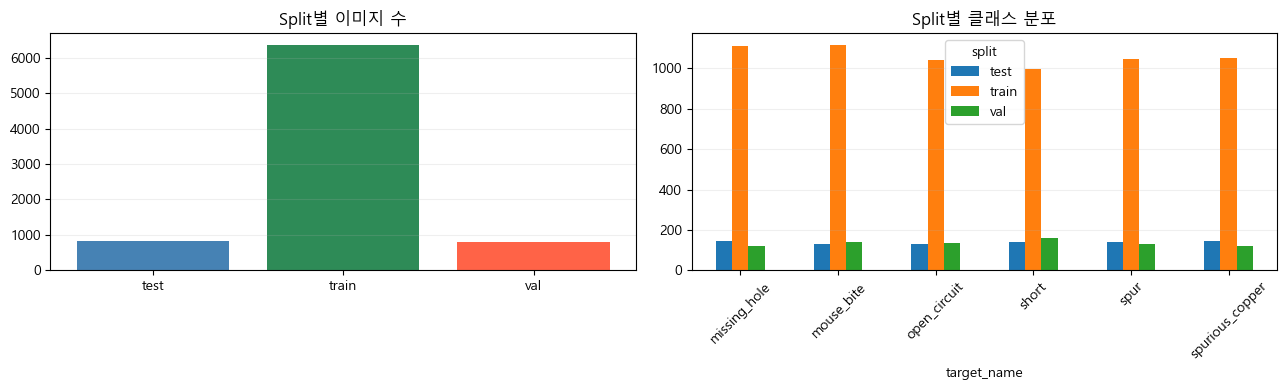

In [4]:
# split/클래스 분포 확인
split_counts = img_df.groupby("split").size().rename("images").reset_index()
class_dist = (
    img_df.groupby(["split", "target_name"]).size()
    .rename("count").reset_index()
)

display(split_counts)
display(class_dist.head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(split_counts["split"], split_counts["images"], color=["steelblue", "seagreen", "tomato"])
axes[0].set_title("Split별 이미지 수")
axes[0].grid(axis="y", alpha=0.2)

pivot = class_dist.pivot(index="target_name", columns="split", values="count").fillna(0)
pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Split별 클래스 분포")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 2) 베이스라인 Feature 추출

빠른 검증을 위해 이미지에서 계산이 가벼운 통계/텍스처 Feature를 사용합니다.

- 밝기 평균/표준편차
- 밝기 분위수
- gradient energy
- edge ratio

In [ ]:
def extract_features(image_path: str):
    g = np.array(Image.open(image_path).convert("L"), dtype=np.float32) / 255.0

    mean = g.mean()
    std = g.std()
    p10, p50, p90 = np.percentile(g, [10, 50, 90])

    gx = np.diff(g, axis=1)
    gy = np.diff(g, axis=0)
    grad_energy = (gx**2).mean() + (gy**2).mean()
    edge_ratio = (np.abs(gx) > 0.08).mean()

    return {
        "f_mean": mean,
        "f_std": std,
        "f_p10": p10,
        "f_p50": p50,
        "f_p90": p90,
        "f_grad_energy": grad_energy,
        "f_edge_ratio": edge_ratio,
    }

feat_rows = []
for _, r in img_df.iterrows():
    feat = extract_features(r["image_path"])
    feat_rows.append({**r.to_dict(), **feat})

dataset = pd.DataFrame(feat_rows)
feature_cols = [c for c in dataset.columns if c.startswith("f_")]

print("최종 학습 테이블 shape:", dataset.shape)
display(dataset.head())

dataset.to_csv(OUT_DIR / "image_classification_table.csv", index=False, encoding="utf-8-sig")
# RTX 3060 : 약 4.5분 소요

최종 학습 테이블 shape: (8001, 14)


,split,stem,image_path,label_path,num_boxes,target_class,target_name,f_mean,f_std,f_p10,f_p50,f_p90,f_grad_energy,f_edge_ratio
0,train,l_light_01_missing_hole_01_1_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole,0.360000,0.132436,0.235294,0.329412,0.592157,0.004175,0.064594
1,train,l_light_01_missing_hole_01_2_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,2,2,missing_hole,0.332902,0.106886,0.227451,0.321569,0.466667,0.003794,0.065111
2,train,l_light_01_missing_hole_02_1_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,2,2,missing_hole,0.369449,0.129446,0.235294,0.341176,0.584314,0.004959,0.079900
3,train,l_light_01_missing_hole_02_2_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole,0.359921,0.132340,0.235294,0.329412,0.588235,0.004172,0.064594
4,train,l_light_01_missing_hole_02_3_600,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset...,1,2,missing_hole,0.333136,0.107232,0.227451,0.321569,0.466667,0.003801,0.065189


## 3) 모델 학습: Nearest Centroid Baseline

복잡한 딥러닝 전에, 해석 쉬운 baseline으로 데이터/라벨 품질을 먼저 확인합니다.

학습 절차:
1. train에서 클래스별 feature 중심(centroid) 계산
2. val/test 샘플을 가장 가까운 centroid 클래스로 예측

In [6]:
def fit_nearest_centroid(df_train, features, target_col="target_class"):
    centroids = df_train.groupby(target_col)[features].mean()
    return centroids


def predict_nearest_centroid(df, centroids, features):
    X = df[features].to_numpy(dtype=np.float32)
    C = centroids.to_numpy(dtype=np.float32)  # (num_class, d)
    cls_ids = centroids.index.to_numpy()

    # 거리 계산: (N, num_class)
    d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    pred_idx = d2.argmin(axis=1)
    preds = cls_ids[pred_idx]
    return preds

train_df = dataset[dataset["split"] == "train"].copy()
val_df = dataset[dataset["split"] == "val"].copy()
test_df = dataset[dataset["split"] == "test"].copy()

centroids = fit_nearest_centroid(train_df, feature_cols)
val_df["pred"] = predict_nearest_centroid(val_df, centroids, feature_cols)
test_df["pred"] = predict_nearest_centroid(test_df, centroids, feature_cols)

display(centroids)
print("train/val/test size:", len(train_df), len(val_df), len(test_df))

,f_mean,f_std,f_p10,f_p50,f_p90,f_grad_energy,f_edge_ratio
target_class,,,,,,,
0,0.393005,0.126907,0.261019,0.370241,0.587148,0.003783,0.052877
1,0.393061,0.126219,0.261868,0.370914,0.583699,0.003766,0.053100
2,0.393096,0.126216,0.262777,0.370399,0.585733,0.003848,0.054871
3,0.394358,0.127502,0.262863,0.371108,0.589119,0.003864,0.054673
4,0.392460,0.127133,0.260916,0.369478,0.586565,0.003784,0.053284
5,0.393065,0.126656,0.261714,0.370268,0.586442,0.003763,0.052664


train/val/test size: 6370 802 829


In [7]:
def classification_report_basic(y_true, y_pred, class_ids):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    cm = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(y_pred, name="pred"),
        dropna=False,
    ).reindex(index=class_ids, columns=class_ids, fill_value=0)

    metrics = []
    for c in class_ids:
        tp = cm.loc[c, c]
        fp = cm[c].sum() - tp
        fn = cm.loc[c].sum() - tp

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        metrics.append({
            "class_id": c,
            "class_name": CLASS_NAMES.get(c, str(c)),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": int(cm.loc[c].sum()),
        })

    mdf = pd.DataFrame(metrics)
    acc = (y_true == y_pred).mean()
    macro_p = mdf["precision"].mean()
    macro_r = mdf["recall"].mean()
    macro_f1 = mdf["f1"].mean()

    summary = {
        "accuracy": float(acc),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
    }
    return summary, mdf, cm

class_ids = sorted(CLASS_NAMES.keys())
val_summary, val_cls_report, val_cm = classification_report_basic(val_df["target_class"], val_df["pred"], class_ids)
test_summary, test_cls_report, test_cm = classification_report_basic(test_df["target_class"], test_df["pred"], class_ids)

print("[VAL]", val_summary)
print("[TEST]", test_summary)

display(val_cls_report)
display(test_cls_report)

[VAL] {'accuracy': 0.18079800498753118, 'macro_precision': 0.22325787408564624, 'macro_recall': 0.1701539893727798, 'macro_f1': 0.13124425047772337}
[TEST] {'accuracy': 0.1881785283474065, 'macro_precision': 0.15603266258676016, 'macro_recall': 0.18809661153871285, 'macro_f1': 0.13817291791397698}


,class_id,class_name,precision,recall,f1,support
0,0,mouse_bite,0.500000,0.014286,0.027778,140
1,1,spur,0.159468,0.369231,0.222738,130
2,2,missing_hole,0.212121,0.059322,0.092715,118
3,3,short,0.220820,0.443038,0.294737,158
4,4,open_circuit,0.122137,0.118519,0.120301,135
5,5,spurious_copper,0.125000,0.016529,0.029197,121


,class_id,class_name,precision,recall,f1,support
0,0,mouse_bite,0.000000,0.000000,0.000000,131
1,1,spur,0.189711,0.427536,0.262806,138
2,2,missing_hole,0.166667,0.027586,0.047337,145
3,3,short,0.193252,0.443662,0.269231,142
4,4,open_circuit,0.186567,0.195312,0.190840,128
5,5,spurious_copper,0.200000,0.034483,0.058824,145


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24020\2500853775.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


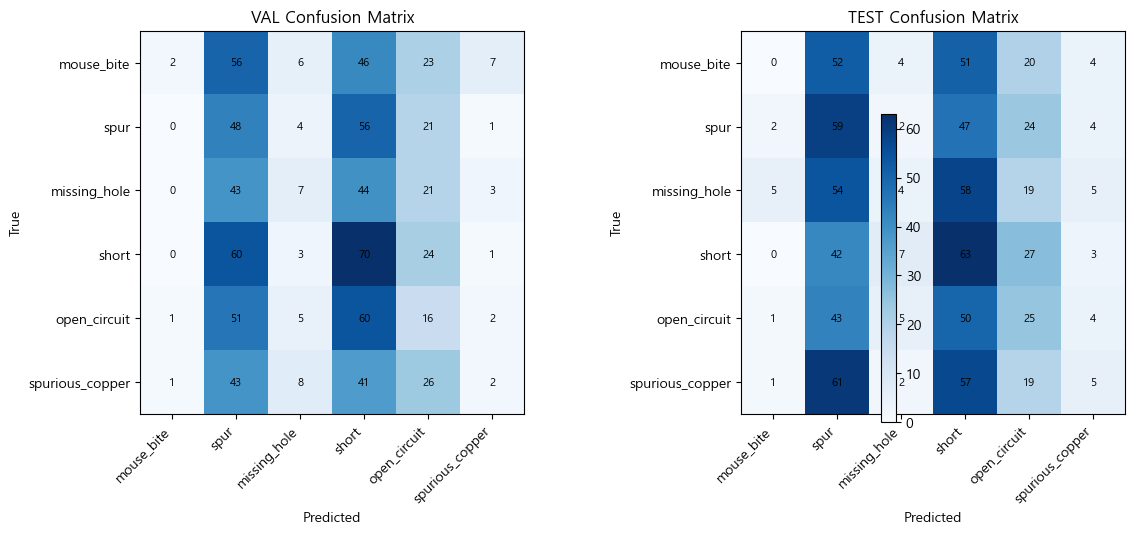

In [8]:
# confusion matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in [
    (axes[0], val_cm, "VAL Confusion Matrix"),
    (axes[1], test_cm, "TEST Confusion Matrix"),
]:
    im = ax.imshow(cm.values, cmap="Blues")
    ax.set_xticks(range(len(class_ids)))
    ax.set_yticks(range(len(class_ids)))
    ax.set_xticklabels([CLASS_NAMES[i] for i in class_ids], rotation=45, ha="right")
    ax.set_yticklabels([CLASS_NAMES[i] for i in class_ids])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm.values[i, j]), ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

In [9]:
# 평가 결과 저장
val_cls_report.to_csv(OUT_DIR / "val_class_report.csv", index=False, encoding="utf-8-sig")
test_cls_report.to_csv(OUT_DIR / "test_class_report.csv", index=False, encoding="utf-8-sig")
val_cm.to_csv(OUT_DIR / "val_confusion_matrix.csv", encoding="utf-8-sig")
test_cm.to_csv(OUT_DIR / "test_confusion_matrix.csv", encoding="utf-8-sig")

summary_df = pd.DataFrame([
    {"split": "val", **val_summary},
    {"split": "test", **test_summary},
])
summary_df.to_csv(OUT_DIR / "summary_metrics.csv", index=False, encoding="utf-8-sig")

display(summary_df)
print("저장 완료:")
for fn in [
    "image_classification_table.csv",
    "val_class_report.csv",
    "test_class_report.csv",
    "val_confusion_matrix.csv",
    "test_confusion_matrix.csv",
    "summary_metrics.csv",
]:
    print("-", OUT_DIR / fn)

,split,accuracy,macro_precision,macro_recall,macro_f1
0,val,0.180798,0.223258,0.170154,0.131244
1,test,0.188179,0.156033,0.188097,0.138173


저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\image_classification_table.csv
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\val_class_report.csv
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\test_class_report.csv
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\val_confusion_matrix.csv
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\test_confusion_matrix.csv
- C:\MyCursorLab\10_프로젝트\outputs\model_eval\summary_metrics.csv


## 4) 해석 및 개선 포인트

- 이 baseline은 데이터 파이프라인 점검용입니다.
- 낮은 성능 클래스는 보통 다음 원인이 큽니다.
  - 클래스 불균형
  - 유사 결함 간 feature 중첩
  - 이미지 단위 라벨 변환 손실(객체 검출 → 단일 클래스)

### 개선 방향
1. 객체 검출 모델(YOLOv8 등)로 직접 학습
2. texture/shape feature 추가 (LBP, GLCM 등)
3. 센서 feature와 결합한 멀티모달 분류
4. 클래스 가중치/재샘플링 적용

## 실습 과제

1. 대표 클래스 규칙을 `최대 bbox 면적 클래스`로 바꿔 성능을 비교하세요.
2. feature를 7개에서 15개 이상으로 확장해 Macro F1 변화를 확인하세요.
3. train 데이터 일부로만 학습하여 데이터 크기-성능 곡선을 만들어 보세요.
4. 동일 파이프라인으로 `val` 성능을 기준으로 모델 선택 규칙을 정의하세요.

---

### 한 줄 정리
시각 데이터 구성 품질이 좋아야, 모델 성능 평가 결과도 신뢰할 수 있습니다.